# 02 - Preprocessing, PyTorch Image Data Augmentation (.pt), Balancing & PCA

This notebook executes the complete preprocessing workflow using modular functions from `src/preprocessing.py`:
1. **PyTorch Image Data Augmentation & Tensor Saving:** Applying robust transformations to raw MRI images and saving them as `.pt` tensor files into `data/processed/augmented_images/`.
2. **Tabular Feature Extraction & Preprocessing:** Extracting OpenCV features, applying SMOTE, tabular data augmentation, and PCA down to 30 components (~98.7% variance).

In [19]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Add src directory to path to import custom modules
sys.path.append(os.path.abspath(os.path.join('..')))
from src.preprocessing import preprocess_tabular_data, extract_image_components, create_nsame_values, process_and_save_augmented_tensors

%matplotlib inline
sns.set_theme(style="whitegrid")
load_dotenv()

True

## 1. Path Configuration & Directories Setup

In [20]:
DATA_DIR = os.getenv("DATA_DIR", "brain_tumor_dataset")
PROCESSED_DIR = os.getenv("PROCESSED_DIR", os.path.join("data", "processed"))
AUGMENTED_TENSORS_DIR = os.path.join(PROCESSED_DIR, "augmented_images")

os.makedirs(PROCESSED_DIR, exist_ok=True)

yes_dir = os.path.join(DATA_DIR, "yes")
no_dir = os.path.join(DATA_DIR, "no")

## 2. Detailed Data Augmentation Strategy

To improve model generalization and prevent overfitting on a limited medical imaging dataset, we implement two levels of data augmentation:

### A. Image Data Augmentation (PyTorch Pipeline)
Before converting images into tensors and saving them as `.pt` files, we apply the following randomized transformations:
- **Resizing (`Resize(32, 32)`):** Standardizes spatial dimensions for the CNN architecture.
- **Random Horizontal Flip (`p=0.5`):** Flips the brain MRI horizontally to simulate anatomical variations and avoid left/right orientation bias.
- **Random Rotation (`degrees=15`):** Rotates the scan slightly (up to ±15°) to account for patient head tilt differences during the MRI acquisition process.
- **Color Jitter (`brightness=0.2, contrast=0.2`):** Randomly alters brightness and contrast to simulate scanner variations, lighting discrepancies, and differences across medical equipment.
- **Normalization:** Scales pixel intensity values into the $[-1, 1]$ range for stable gradient descent convergence.

In [27]:
if os.path.exists(yes_dir) and os.path.exists(no_dir):
    print("Starting PyTorch image data augmentation and tensor saving...")
    process_and_save_augmented_tensors(DATA_DIR, AUGMENTED_TENSORS_DIR, num_augmentations=2)
    process_and_save_augmented_tensors(DATA_DIR, AUGMENTED_TENSORS_DIR+"_224x224", num_augmentations=2, img_size=(224, 224))
else:
    print("⚠️ Raw dataset directories not found.")

Starting PyTorch image data augmentation and tensor saving...
Augmenting and saving tensors for class 'yes': 155 source images.
Augmenting and saving tensors for class 'no': 98 source images.
All augmented tensors successfully saved as .pt files!
Augmenting and saving tensors for class 'yes': 155 source images.
Augmenting and saving tensors for class 'no': 98 source images.
All augmented tensors successfully saved as .pt files!


## 3. Tabular Feature Extraction & Saving

In [22]:
if os.path.exists(yes_dir) and os.path.exists(no_dir):
    print("Extracting features for 'yes' class...")
    yes_dataset = extract_image_components(yes_dir)
    labels_yes = create_nsame_values('yes', len(yes_dataset[list(yes_dataset.keys())[0]]))
    
    print("Extracting features for 'no' class...")
    no_dataset = extract_image_components(no_dir)
    labels_no = create_nsame_values('no', len(no_dataset[list(no_dataset.keys())[0]]))
    
    yes_dataset['labels'] = labels_yes
    no_dataset['labels'] = labels_no
    
    df_yes = pd.DataFrame(yes_dataset)
    df_no = pd.DataFrame(no_dataset)
    df_features = pd.concat([df_yes, df_no], ignore_index=True)
    
    output_csv_path = os.path.join(PROCESSED_DIR, "tumor_features.csv")
    df_features.to_csv(output_csv_path, index=False)
    print(f"Raw tabular features saved to: {output_csv_path} with shape: {df_features.shape}")
else:
    print("⚠️ Dataset directories not found.")

Extracting features for 'yes' class...
Extracting features for 'no' class...
Raw tabular features saved to: ../data/processed\tumor_features.csv with shape: (253, 1034)


## 4. Advanced Tabular Preprocessing, Balancing (SMOTE), Tabular Augmentation & PCA

### B. Tabular Data Augmentation (Gaussian Noise)
For classical machine learning, we apply a minor **Gaussian noise augmentation** (`noise_factor=0.01`) directly to the standardized feature matrix. This introduces subtle numerical jitter, helping tree-based models and classifiers generalize better and prevent overfitting on exact numerical thresholds.

In [23]:
csv_path = os.path.join(PROCESSED_DIR, "tumor_features.csv")
df_raw = pd.read_csv(csv_path)

print("Original class distribution:")
print(df_raw['labels'].value_counts())

X_pca, y_balanced, pca_model, scaler_model = preprocess_tabular_data(
    df_raw, 
    target_col='labels', 
    n_components=30, 
    apply_smote=True,
    apply_augmentation=True
)

print(f"\nAfter balancing, augmentation, and PCA reduction:")
print(f"Features shape (X_pca): {X_pca.shape}")
print(f"Labels shape (y_balanced): {y_balanced.shape}")

Original class distribution:
labels
yes    155
no      98
Name: count, dtype: int64

After balancing, augmentation, and PCA reduction:
Features shape (X_pca): (620, 30)
Labels shape (y_balanced): (620,)


c:\Users\ihadi\Desktop\pythonenv\.venvComputerVision\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


## 5. Explained Variance Analysis for PCA

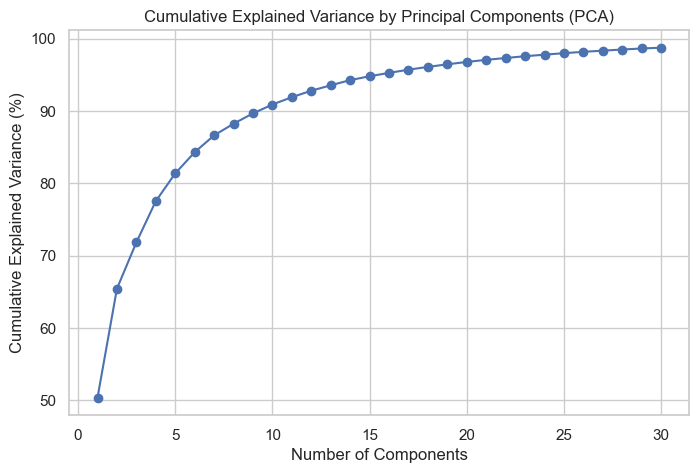

Total variance explained by 30 components: 98.74%


In [24]:
explained_variance = np.cumsum(pca_model.explained_variance_ratio_) * 100

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='-', color='b')
plt.title('Cumulative Explained Variance by Principal Components (PCA)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.grid(True)
plt.show()

print(f"Total variance explained by {len(explained_variance)} components: {explained_variance[-1]:.2f}%")